# SAP S/4HANA Procure-to-Pay (MM Module) Simulation

# Project Objective
Simulate the SAP S/4HANA Materials Management (MM) Procure-to-Pay lifecycle using a real-world procurement dataset and perform vendor performance, cost optimization, and delivery risk analysis.

# SAP Lifecycle Mapping (MM → FI Integration)
ME21N – Purchase Order Creation
MIGO – Goods Receipt Posting
MIRO – Invoice Verification
F110 – Automatic Payment Run

Goods receipt updates inventory and triggers accounting postings in FI.
Invoice verification validates vendor invoices against PO and GR.
Payment run processes cleared vendor invoices.

# Key Business Analysis Performed
Total Procurement Spend Analysis
Vendor Spend Ranking
Delivery Delay & Lead Time Analysis
Negotiation Cost Savings Evaluation
Vendor Risk Classification based on Defect Rate

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\narla\Downloads\SAP MM Project\Procurement KPI Analysis Dataset.csv")
df.head()

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance
0,PO-00001,Alpha_Inc,2023-10-17,2023-10-25,Office Supplies,Cancelled,1176,20.13,17.81,NaN,Yes
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes
2,PO-00003,Gamma_Co,2022-01-26,2022-02-15,MRO,Delivered,910,95.51,92.26,41.0,Yes
3,PO-00004,Beta_Supplies,2022-10-09,2022-10-28,Packaging,Delivered,1344,99.85,95.52,112.0,Yes
4,PO-00005,Delta_Logistics,2022-09-08,2022-09-20,Raw Materials,Delivered,1180,64.07,60.53,171.0,No


In [2]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'])

In [3]:
# Goods Receipt Simulation (MIGO)
df['WE_STATUS'] = df['Delivery_Date'].apply(
    lambda x: 'Completed' if pd.notnull(x) else 'Pending'
)

# Invoice Verification Simulation (MIRO)
df['MIRO_STATUS'] = df['Order_Status'].apply(
    lambda x: 'Verified' if x == 'Delivered' else 'Pending'
)

# Payment Run Simulation (F110)
df['F110_STATUS'] = df.apply(
    lambda row: 'Paid' if row['Order_Status'] == 'Delivered' else 'Not Paid',
    axis=1
)

In [4]:
df['TOTAL_VALUE'] = df['Quantity'] * df['Negotiated_Price']

In [5]:
total_spend = df['TOTAL_VALUE'].sum()
print("Total Procurement Spend:", total_spend)

Total Procurement Spend: 45373696.39


In [6]:
df['Delivery_Delay_Days'] = (df['Delivery_Date'] - df['Order_Date']).dt.days

avg_delay = df['Delivery_Delay_Days'].mean()
print("Average Delivery Delay (Days):", avg_delay)

Average Delivery Delay (Days): 10.776811594202899


In [7]:
df['COST_SAVINGS'] = (df['Unit_Price'] - df['Negotiated_Price']) * df['Quantity']

total_savings = df['COST_SAVINGS'].sum()
print("Total Cost Savings from Negotiation:", total_savings)

Total Cost Savings from Negotiation: 3931126.4699999997


In [8]:
df['DEFECT_RATE'] = df['Defective_Units'] / df['Quantity']

In [9]:
df['Vendor_Risk'] = df['DEFECT_RATE'].apply(
    lambda x: 'High Risk' if x > 0.1 else 'Low Risk'
)

In [10]:
vendor_spend = df.groupby('Supplier')['TOTAL_VALUE'].sum().sort_values(ascending=False)
vendor_spend.head()

Supplier
Beta_Supplies      9858665.90
Epsilon_Group      9851156.06
Delta_Logistics    9236240.47
Gamma_Co           8587921.71
Alpha_Inc          7839712.25
Name: TOTAL_VALUE, dtype: float64

In [11]:
pending_rate = (df['WE_STATUS'] == 'Pending').mean() * 100
print("Pending Delivery %:", pending_rate)

Pending Delivery %: 11.196911196911197


In [12]:
df['DEFECT_RATE'] = df['Defective_Units'] / df['Quantity']
df.groupby('Supplier')['DEFECT_RATE'].mean()

Supplier
Alpha_Inc          0.023590
Beta_Supplies      0.097764
Delta_Logistics    0.146314
Epsilon_Group      0.030684
Gamma_Co           0.050246
Name: DEFECT_RATE, dtype: float64

In [13]:
df.to_csv(r"C:\Users\narla\Downloads\SAP MM Project\sap_mm_simulated_dataset.csv", index=False)

In [14]:
pd.read_csv("sap_mm_simulated_dataset.csv").head()

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance,WE_STATUS,MIRO_STATUS,F110_STATUS,TOTAL_VALUE,Delivery_Delay_Days,COST_SAVINGS,DEFECT_RATE,Vendor_Risk
0,PO-00001,Alpha_Inc,2023-10-17,2023-10-25,Office Supplies,Cancelled,1176,20.13,17.81,NaN,Yes,Completed,Pending,Not Paid,20944.56,8.0,2728.32,NaN,Low Risk
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes,Completed,Verified,Paid,56346.06,10.0,2987.82,0.155732,High Risk
2,PO-00003,Gamma_Co,2022-01-26,2022-02-15,MRO,Delivered,910,95.51,92.26,41.0,Yes,Completed,Verified,Paid,83956.60,20.0,2957.50,0.045055,Low Risk
3,PO-00004,Beta_Supplies,2022-10-09,2022-10-28,Packaging,Delivered,1344,99.85,95.52,112.0,Yes,Completed,Verified,Paid,128378.88,19.0,5819.52,0.083333,Low Risk
4,PO-00005,Delta_Logistics,2022-09-08,2022-09-20,Raw Materials,Delivered,1180,64.07,60.53,171.0,No,Completed,Verified,Paid,71425.40,12.0,4177.20,0.144915,High Risk


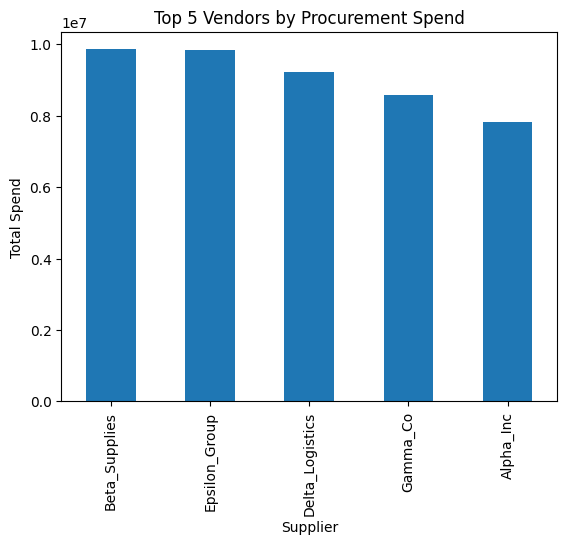

In [15]:
import matplotlib.pyplot as plt

vendor_spend.head(5).plot(kind='bar')
plt.title("Top 5 Vendors by Procurement Spend")
plt.ylabel("Total Spend")
plt.show()